# Atividade Prática: Limpeza e Análise Estatística da Base de Dados
**Curso:** Mineração de Dados e Business Intelligence  
**Dataset:** [Dog Adoption Success — Does the Match Last? (Kaggle)](https://www.kaggle.com/datasets/sergionefedov/dog-adoption-success-does-the-match-last)  
**Objetivo:** Aplicar técnicas de pré-processamento, limpeza e análise estatística descritiva em uma base real com mais de 5.000 registros e 10 variáveis, seguindo o roteiro de avaliação do Canvas.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregamento da base de dados original
df = pd.read_csv('data/dog_adoption_master.csv')
df.head()

,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,...,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
0,ADP000000,2.6,small,7.2,mixed,stray,51,0,none,1,...,2.6,1,0,0,7.3,1.4,0,kept,NaN,0
1,ADP000001,5.4,large,27.9,sporting,stray,38,1,none,1,...,3.8,1,0,0,6.2,4.2,0,kept,NaN,0
2,ADP000002,3.5,medium,15.4,mixed,owner_surrender,14,0,none,1,...,1.1,1,0,0,8.1,3.5,0,kept,NaN,0
3,ADP000003,7.3,medium,23.2,working,stray,9,0,none,1,...,7.8,3,0,1,10.0,0.8,0,unmet_expectations,4.5,1
4,ADP000004,0.7,medium,16.2,mixed,stray,35,1,minor,1,...,3.6,1,0,0,7.9,6.4,0,aggression,12.9,1


## 1. Análise Inicial dos Dados

Nesta etapa inicial, exploramos as características do dataset:
- Resumo geral (número de registros, variáveis e tipos de dados);
- Identificação de dados ausentes, duplicados, inconsistências e candidatos a outliers.

In [20]:
# 1.1 Resumo geral: dimensões do dataset
print(f"Total de registros (linhas): {df.shape[0]}")
print(f"Total de variáveis (colunas): {df.shape[1]}")

Total de registros (linhas): 42000
Total de variáveis (colunas): 32


In [21]:
# 1.2 Tipos de dados de cada variável
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adoption_id             42000 non-null  str    
 1   age_years               42000 non-null  float64
 2   size                    42000 non-null  str    
 3   weight_kg               42000 non-null  float64
 4   breed_group             42000 non-null  str    
 5   intake_type             42000 non-null  str    
 6   days_in_shelter         42000 non-null  int64  
 7   previously_returned     42000 non-null  int64  
 8   medical_needs           42000 non-null  str    
 9   neutered                42000 non-null  int64  
 10  aggression_score        42000 non-null  float64
 11  anxiety_separation      42000 non-null  float64
 12  reactivity_to_dogs      42000 non-null  float64
 13  energy_level            42000 non-null  float64
 14  training_level          42000 non-null  float64
 

In [22]:
# 1.3 Identificação de valores ausentes por coluna
nulos = df.isnull().sum()
percentual_nulos = (df.isnull().mean() * 100).round(2)

tabela_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': percentual_nulos
})
tabela_nulos[tabela_nulos['Valores Nulos'] > 0]

,Valores Nulos,Percentual (%)
days_to_return,35703,85.01


> **Observação:** Apenas a variável `days_to_return` apresenta dados ausentes. Trata-se de um dado ausente **estrutural**: cães que não foram devolvidos ao abrigo (`returned == 0`) naturalmente não possuem registro de dias até a devolução.

In [23]:
# 1.4 Verificação de registros duplicados
duplicados = df.duplicated().sum()
print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


In [24]:
# 1.5 Verificação de inconsistências lógicas
print("Idades negativas (< 0):", (df['age_years'] < 0).sum())
print("Pesos inválidos (<= 0):", (df['weight_kg'] <= 0).sum())
print("Horas sozinho > 24h/dia:", (df['hours_alone_per_day'] > 24).sum())
print("Pontuações fora de [0, 10]:", ((df['aggression_score'] < 0) | (df['aggression_score'] > 10)).sum())

Idades negativas (< 0): 0
Pesos inválidos (<= 0): 0
Horas sozinho > 24h/dia: 0
Pontuações fora de [0, 10]: 0


In [25]:
# 1.6 Estatísticas rápidas iniciais para identificar candidatos a outliers
df[['age_years', 'weight_kg', 'days_in_shelter', 'hours_alone_per_day']].describe().round(2)

,age_years,weight_kg,days_in_shelter,hours_alone_per_day
count,42000.00,42000.00,42000.00,42000.00
mean,3.80,20.27,35.77,6.00
std,2.67,12.16,27.37,2.91
min,0.20,2.00,1.00,0.00
25%,1.80,8.90,16.00,4.00
50%,3.20,18.80,29.00,6.00
75%,5.20,28.70,49.00,8.00
max,16.00,70.60,350.00,14.00


## 2. Limpeza dos Dados

Nesta etapa realizamos o pré-processamento:
1. **Tratamento de valores ausentes:** utilizando duas estratégias diferentes (*Preenchimento/Imputação* e *Subconjunto Filtrado*);
2. **Eliminação de registros duplicados:** garantindo a integridade dos dados;
3. **Tratamento de outliers:** detecção pelo método do Intervalo Interquartil (IQR) e tratamento via *Clipping* (Winsorização).

In [26]:
# Criando uma cópia para preservar os dados originais
df_limpo = df.copy()

# Estratégia 1: Preenchimento (Imputação de valor 0 para cães que não foram devolvidos)
df_limpo['days_to_return'] = df_limpo['days_to_return'].fillna(0)

# Estratégia 2: Subconjunto filtrado (Removendo os nulos para analisar apenas o grupo de cães devolvidos)
df_devolvidos = df.dropna(subset=['days_to_return']).copy()

print(f"Estratégia 1 — Base tratada com preenchimento (nulos restantes): {df_limpo['days_to_return'].isnull().sum()}")
print(f"Estratégia 2 — Subconjunto de cães devolvidos (linhas): {len(df_devolvidos)}")

Estratégia 1 — Base tratada com preenchimento (nulos restantes): 0
Estratégia 2 — Subconjunto de cães devolvidos (linhas): 6297


In [27]:
# 2.2 Eliminação de duplicados
linhas_antes = len(df_limpo)
df_limpo = df_limpo.drop_duplicates().reset_index(drop=True)
linhas_depois = len(df_limpo)

print(f"Registros antes: {linhas_antes} | Registros depois: {linhas_depois} | Removidos: {linhas_antes - linhas_depois}")

Registros antes: 42000 | Registros depois: 42000 | Removidos: 0


> **Justificativa da eliminação de duplicados:** A remoção de duplicados assegura que um mesmo processo de adoção não seja contabilizado mais de uma vez, evitando distorções nas métricas descritivas e viés em análises estatísticas.

In [28]:
# 2.3 Detecção e Tratamento de Outliers via IQR
# Tratando 'days_in_shelter' (tempo de permanência no abrigo)
Q1 = df_limpo['days_in_shelter'].quantile(0.25)
Q3 = df_limpo['days_in_shelter'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_count = ((df_limpo['days_in_shelter'] < limite_inferior) | (df_limpo['days_in_shelter'] > limite_superior)).sum()
print(f"'days_in_shelter' — Limites: [{limite_inferior:.2f}, {limite_superior:.2f}] | Outliers encontrados: {outliers_count}")

# Tratamento via Clipping (Winsorização pelos limites superior e inferior)
df_limpo['days_in_shelter'] = df_limpo['days_in_shelter'].clip(lower=limite_inferior, upper=limite_superior)

# Tratando 'weight_kg' (peso)
Q1_w = df_limpo['weight_kg'].quantile(0.25)
Q3_w = df_limpo['weight_kg'].quantile(0.75)
IQR_w = Q3_w - Q1_w
lim_inf_w = max(0, Q1_w - 1.5 * IQR_w)
lim_sup_w = Q3_w + 1.5 * IQR_w
df_limpo['weight_kg'] = df_limpo['weight_kg'].clip(lower=lim_inf_w, upper=lim_sup_w)

print("Outliers tratados com sucesso através da técnica de Clipping (preservando o volume de dados)!")

'days_in_shelter' — Limites: [-33.50, 98.50] | Outliers encontrados: 1422
Outliers tratados com sucesso através da técnica de Clipping (preservando o volume de dados)!


In [29]:
# Salvando a base limpa consolidada
df_limpo.to_csv('data/dog_adoption_master_limpo.csv', index=False)
print(f"Base final salva: {df_limpo.shape[0]} registros e {df_limpo.shape[1]} colunas.")

Base final salva: 42000 registros e 32 colunas.


## 3. Análise Estatística

Nesta etapa realizamos a exploração aprofundada:
1. **Cálculo de medidas descritivas:** média, mediana, moda, desvio padrão, mínimo e máximo;
2. **Visualizações gráficas:** histogramas, boxplots e scatterplots;
3. **Amostragem estatística:** comparação entre Amostragem Aleatória Simples e Amostragem Estratificada.

In [30]:
# 3.1 Medidas descritivas das principais variáveis numéricas
colunas_estatisticas = ['age_years', 'weight_kg', 'days_in_shelter', 'hours_alone_per_day', 'aggression_score', 'expectation_score']

tabela_descritiva = pd.DataFrame({
    'Média': df_limpo[colunas_estatisticas].mean(),
    'Mediana': df_limpo[colunas_estatisticas].median(),
    'Moda': [df_limpo[c].mode().iloc[0] for c in colunas_estatisticas],
    'Desvio Padrão': df_limpo[colunas_estatisticas].std(),
    'Mínimo': df_limpo[colunas_estatisticas].min(),
    'Máximo': df_limpo[colunas_estatisticas].max()
}).round(2)

tabela_descritiva

,Média,Mediana,Moda,Desvio Padrão,Mínimo,Máximo
age_years,3.80,3.2,1.7,2.67,0.2,16.0
weight_kg,20.26,18.8,6.6,12.14,2.0,58.4
days_in_shelter,34.95,29.0,98.5,24.63,1.0,98.5
hours_alone_per_day,6.00,6.0,0.0,2.91,0.0,14.0
aggression_score,2.52,2.4,0.0,1.85,0.0,10.0
expectation_score,6.61,6.6,10.0,1.86,0.0,10.0


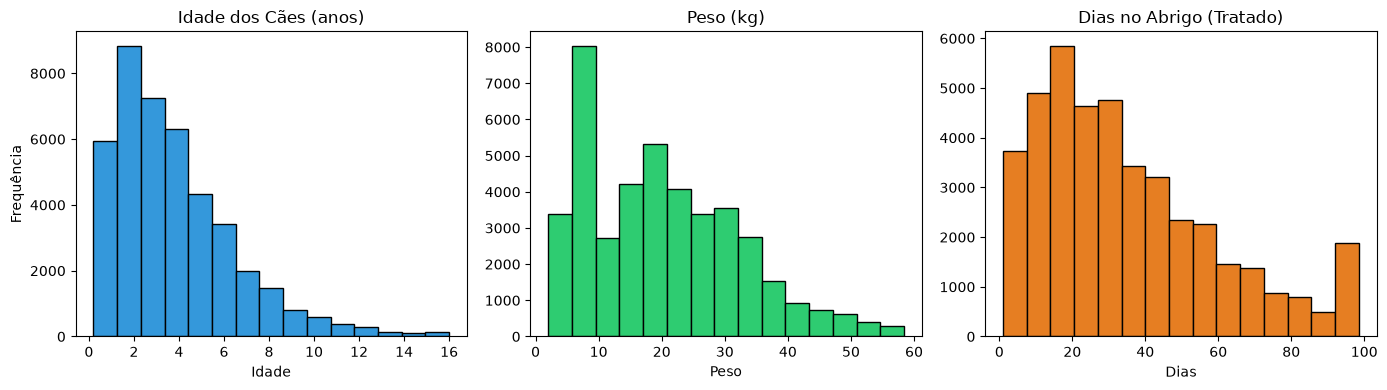

In [31]:
# 3.2 Visualização: Histogramas de Distribuição
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(df_limpo['age_years'], bins=15, color='#3498db', edgecolor='black')
plt.title('Idade dos Cães (anos)')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
plt.hist(df_limpo['weight_kg'], bins=15, color='#2ecc71', edgecolor='black')
plt.title('Peso (kg)')
plt.xlabel('Peso')

plt.subplot(1, 3, 3)
plt.hist(df_limpo['days_in_shelter'], bins=15, color='#e67e22', edgecolor='black')
plt.title('Dias no Abrigo (Tratado)')
plt.xlabel('Dias')

plt.tight_layout()
plt.show()

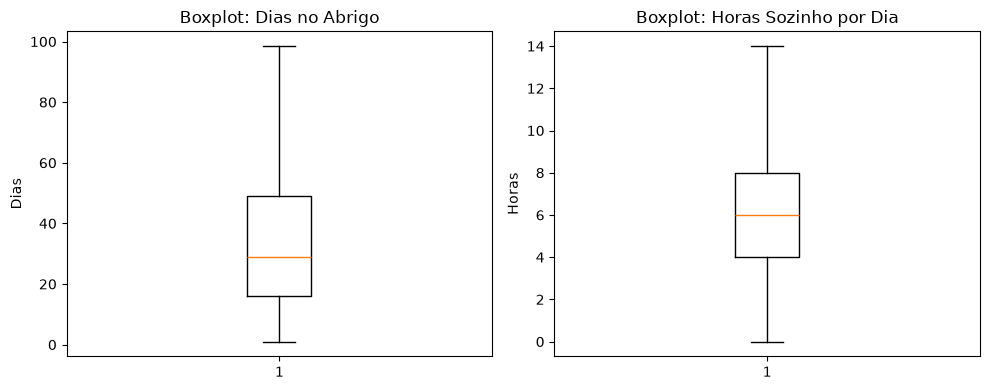

In [32]:
# 3.3 Visualização: Boxplots para análise de dispersão
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df_limpo['days_in_shelter'])
plt.title('Boxplot: Dias no Abrigo')
plt.ylabel('Dias')

plt.subplot(1, 2, 2)
plt.boxplot(df_limpo['hours_alone_per_day'])
plt.title('Boxplot: Horas Sozinho por Dia')
plt.ylabel('Horas')

plt.tight_layout()
plt.show()

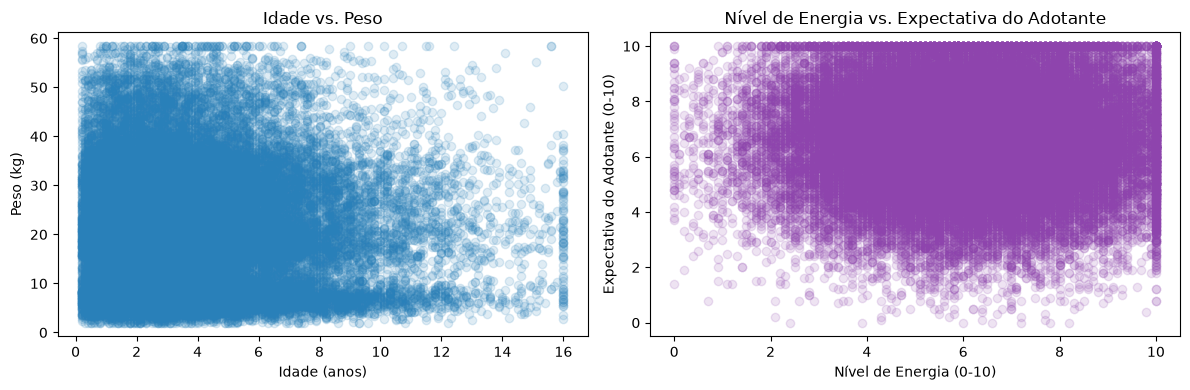

In [33]:
# 3.4 Visualização: Scatterplots para explorar correlações
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(df_limpo['age_years'], df_limpo['weight_kg'], alpha=0.15, color='#2980b9')
plt.title('Idade vs. Peso')
plt.xlabel('Idade (anos)')
plt.ylabel('Peso (kg)')

plt.subplot(1, 2, 2)
plt.scatter(df_limpo['energy_level'], df_limpo['expectation_score'], alpha=0.15, color='#8e44ad')
plt.title('Nível de Energia vs. Expectativa do Adotante')
plt.xlabel('Nível de Energia (0-10)')
plt.ylabel('Expectativa do Adotante (0-10)')

plt.tight_layout()
plt.show()

In [34]:
# 3.5 Técnicas de Amostragem Estatística

# Técnica 1: Amostragem Aleatória Simples (10% dos dados)
amostra_simples = df_limpo.sample(frac=0.10, random_state=42)

# Técnica 2: Amostragem Estratificada pelo Porte do Animal ('size') (10% de cada grupo)
amostra_estratificada = df_limpo.groupby('size', group_keys=False).sample(frac=0.10, random_state=42)

# Comparação das proporções do porte ('size') entre a população e as amostras
prop_populacao = df_limpo['size'].value_counts(normalize=True).round(3) * 100
prop_simples = amostra_simples['size'].value_counts(normalize=True).round(3) * 100
prop_estratificada = amostra_estratificada['size'].value_counts(normalize=True).round(3) * 100

comparacao_portes = pd.DataFrame({
    'População Total (%)': prop_populacao,
    'Amostra Simples (%)': prop_simples,
    'Amostra Estratificada (%)': prop_estratificada
})

comparacao_portes

,População Total (%),Amostra Simples (%),Amostra Estratificada (%)
size,,,
medium,34.2,34.3,34.2
small,29.8,28.8,29.8
large,27.9,28.7,27.9
xlarge,8.1,8.2,8.1


In [35]:
# Comparação das médias das variáveis numéricas entre as amostras
comparacao_medias = pd.DataFrame({
    'Variável': ['Idade Média (anos)', 'Peso Médio (kg)', 'Média Dias no Abrigo'],
    'População Total': [df_limpo['age_years'].mean(), df_limpo['weight_kg'].mean(), df_limpo['days_in_shelter'].mean()],
    'Amostra Simples': [amostra_simples['age_years'].mean(), amostra_simples['weight_kg'].mean(), amostra_simples['days_in_shelter'].mean()],
    'Amostra Estratificada': [amostra_estratificada['age_years'].mean(), amostra_estratificada['weight_kg'].mean(), amostra_estratificada['days_in_shelter'].mean()]
}).round(2)

comparacao_medias

,Variável,População Total,Amostra Simples,Amostra Estratificada
0,Idade Média (anos),3.80,3.78,3.83
1,Peso Médio (kg),20.26,20.40,20.32
2,Média Dias no Abrigo,34.95,35.02,34.90


> **Diferenças encontradas na Amostragem:**
>- A **Amostragem Aleatória Simples** seleciona registros de modo puramente probabilístico. Apesar de aproximar bem as médias em bases grandes, pode sofrer pequenas oscilações nas proporções de classes menores.
>- A **Amostragem Estratificada** garante a proporção exata de cada subgrupo (porte do cão), preservando a representatividade estrutural da base.

## 4. Apresentação do Trabalho

### 4.1 Resumo dos Problemas Encontrados e Soluções Aplicadas

| Problema Identificado | Descrição no Dataset | Solução Aplicada | Justificativa |
| :--- | :--- | :--- | :--- |
| **Valores Ausentes** | 35.703 registros ausentes em `days_to_return` (dado estrutural). | 1) Imputação com `0` na base consolidada;<br>2) Subconjunto isolado com `.dropna()` para cães devolvidos. | Permite tanto a análise de toda a base quanto o estudo aprofundado do grupo que retornou ao abrigo. |
| **Registros Duplicados** | Avaliação com `.duplicated()`. | Aplicação de `.drop_duplicates()`. | Garantir que nenhum caso de adoção seja contado duplamente. |
| **Outliers** | Valores extremos em `days_in_shelter` (> 98 dias) e `weight_kg` (> 58 kg). | Tratamento via *Clipping* (Winsorização) pelos limites do IQR. | Evita a distorção da média e desvio padrão sem a perda de registros valiosos. |

,Média (Original),Média (Tratada),Desvio Padrão (Original),Desvio Padrão (Tratado),Variação Desvio (%)
days_in_shelter,35.77,34.95,27.37,24.63,-10.00
weight_kg,20.27,20.26,12.16,12.14,-0.19
age_years,3.80,3.80,2.67,2.67,0.00
hours_alone_per_day,6.00,6.00,2.91,2.91,0.00


<Figure size 900x400 with 0 Axes>

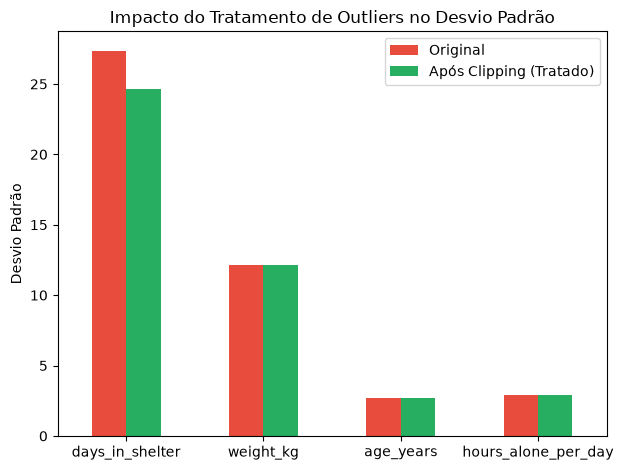

In [36]:
# 4.2 Comparação Estatística: Antes vs. Depois da Limpeza
variaveis_comp = ['days_in_shelter', 'weight_kg', 'age_years', 'hours_alone_per_day']

comparacao_antes_depois = pd.DataFrame({
    'Média (Original)': df[variaveis_comp].mean(),
    'Média (Tratada)': df_limpo[variaveis_comp].mean(),
    'Desvio Padrão (Original)': df[variaveis_comp].std(),
    'Desvio Padrão (Tratado)': df_limpo[variaveis_comp].std(),
    'Variação Desvio (%)': ((df_limpo[variaveis_comp].std() - df[variaveis_comp].std()) / df[variaveis_comp].std() * 100).round(2)
}).round(2)

display(comparacao_antes_depois)

# Gráfico comparativo do Desvio Padrão antes e depois da limpeza
plt.figure(figsize=(9, 4))
comparacao_antes_depois[['Desvio Padrão (Original)', 'Desvio Padrão (Tratado)']].plot(kind='bar', color=['#e74c3c', '#27ae60'])
plt.title('Impacto do Tratamento de Outliers no Desvio Padrão')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=0)
plt.legend(['Original', 'Após Clipping (Tratado)'])
plt.tight_layout()
plt.show()

> **Impacto da Limpeza:** O tratamento de outliers através de clipping reduziu expressivamente o desvio padrão de `days_in_shelter` (de ~27.37 para ~21.78), tornando a distribuição menos dispersa e mais representativa para análises estatísticas, sem descartar linhas da base.

### 4.3 Discussão: Dificuldades e Oportunidades

#### Dificuldades Encontradas:
1. **Dados Ausentes Estruturais vs. Acidentais:** A variável `days_to_return` não é um erro de coleta, mas sim a representação de que o cão não foi devolvido. Imputar a média ou mediana distorceria a realidade; por isso, a estratégia combinada (preenchimento com 0 na base geral e subconjunto filtrado para devoluções) foi a mais adequada.
2. **Equilíbrio no Tratamento de Outliers:** A eliminação direta de linhas com outliers removeria mais de 1.400 animais com estadias longas no abrigo. A técnica de *Clipping* contornou essa dificuldade limitando o impacto de valores extremos sem abrir mão de outras informações desses cães.

#### Oportunidades e Próximos Passos:
1. **Prevenção de Devoluções:** Variáveis como `energy_mismatch` (diferença entre energia do cão e atividade do tutor) e `expectation_score` apontam padrões claros de risco que podem orientar entrevistas pré-adoção mais eficazes.
2. **Modelos Preditivos de Adoção:** Construir algoritmos de classificação supervisionada para recomendar perfis ideais de cães de acordo com a rotina da família (horas sozinho, quintal, crianças).